# Fashion-MNIST Dataset - GAN

### [Fashion-MNIST Dataset](https://github.com/zalandoresearch/fashion-mnist)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Han Xiao, Kashif Rasul, Roland Vollgraf, https://github.com/zalandoresearch/fashion-mnist

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy matplotlib

## Import Libraries

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
%matplotlib inline

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
IMAGE_SIZE = 28
IMAGE_SIZE

28

In [6]:
LATENT_DIM = 64
LATENT_DIM

64

In [7]:
HIDDEN_DIM = 256
HIDDEN_DIM

256

## Hyperparameters

In [8]:
LEARNING_RATE = 0.0002
LEARNING_RATE

0.0002

In [9]:
EPOCHS = 30
EPOCHS

30

In [10]:
BATCH_SIZE = 128
BATCH_SIZE

128

## Device

In [11]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Load Dataset

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.FashionMNIST('data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
len(train_data)

60000

## Create Generator

In [13]:
class Generator(nn.Module):
    """
    A generator that maps noise to 28x28 images.
    """

    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        """
        Initialize the generator layers.

        Parameters:
            latent_dim (int): Size of the noise vector.
            hidden_dim (int): Hidden layer size.

        Returns:
            None
        """
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, IMAGE_SIZE * IMAGE_SIZE),
            nn.Tanh())

    def forward(self, z):
        """
        Generate a batch of images from noise.

        Parameters:
            z (torch.Tensor): Noise batch.

        Returns:
            torch.Tensor: Batch of images.
        """
        images = self.net(z)
        return images.view(z.size(0), 1, IMAGE_SIZE, IMAGE_SIZE)

## Create Discriminator

In [14]:
class Discriminator(nn.Module):
    """
    A discriminator that scores images as real or fake.
    """

    def __init__(self, hidden_dim=HIDDEN_DIM):
        """
        Initialize the discriminator layers.

        Parameters:
            hidden_dim (int): Hidden layer size.

        Returns:
            None
        """
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMAGE_SIZE * IMAGE_SIZE, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1))

    def forward(self, x):
        """
        Score a batch of images.

        Parameters:
            x (torch.Tensor): Batch of images.

        Returns:
            torch.Tensor: Logits for each image.
        """
        return self.net(x)

## Instantiate Models, Loss, and Optimizers

In [15]:
torch.manual_seed(SEED)
generator = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
opt_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
generator

Generator(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Tanh()
  )
)

## Train Model

### Functions

In [16]:
def discriminator_loss(disc, gen, real, loss_fn, latent_dim):
    """
    Compute the discriminator loss on real and fake images.

    Parameters:
        disc (nn.Module): The discriminator.
        gen (nn.Module): The generator.
        real (torch.Tensor): Batch of real images.
        loss_fn (nn.Module): Binary cross-entropy loss.
        latent_dim (int): Size of the noise vector.

    Returns:
        torch.Tensor: The discriminator loss.
    """
    noise = torch.randn(real.size(0), latent_dim, device=real.device)
    fake = gen(noise)
    real_logits = disc(real)
    fake_logits = disc(fake.detach())
    real_loss = loss_fn(real_logits, torch.ones_like(real_logits))
    fake_loss = loss_fn(fake_logits, torch.zeros_like(fake_logits))
    return real_loss + fake_loss


def generator_loss(disc, gen, batch_size, loss_fn, latent_dim):
    """
    Compute the generator loss from the discriminator scores.

    Parameters:
        disc (nn.Module): The discriminator.
        gen (nn.Module): The generator.
        batch_size (int): Number of images to generate.
        loss_fn (nn.Module): Binary cross-entropy loss.
        latent_dim (int): Size of the noise vector.

    Returns:
        torch.Tensor: The generator loss.
    """
    noise = torch.randn(batch_size, latent_dim, device=DEVICE)
    fake_logits = disc(gen(noise))
    return loss_fn(fake_logits, torch.ones_like(fake_logits))


def train_epoch(disc, gen, loader, loss_fn, opt_d, opt_g, latent_dim):
    """
    Train the discriminator and generator for one epoch.

    Parameters:
        disc (nn.Module): The discriminator.
        gen (nn.Module): The generator.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Binary cross-entropy loss.
        opt_d (torch.optim.Optimizer): Discriminator optimizer.
        opt_g (torch.optim.Optimizer): Generator optimizer.
        latent_dim (int): Size of the noise vector.

    Returns:
        tuple: Mean discriminator and generator loss.
    """
    disc.train()
    gen.train()
    total_d, total_g = 0.0, 0.0
    for real, _ in loader:
        real = real.to(DEVICE)
        opt_d.zero_grad()
        d_loss = discriminator_loss(disc, gen, real, loss_fn, latent_dim)
        d_loss.backward()
        opt_d.step()
        opt_g.zero_grad()
        g_loss = generator_loss(disc, gen, real.size(0), loss_fn, latent_dim)
        g_loss.backward()
        opt_g.step()
        total_d += d_loss.item() * len(real)
        total_g += g_loss.item() * len(real)
    n = len(loader.dataset)
    return total_d / n, total_g / n

### Training Loop

In [17]:
history_d = []
history_g = []
for epoch in range(EPOCHS):
    d_loss, g_loss = train_epoch(discriminator, generator, train_loader,
                                 loss_fn, opt_d, opt_g, LATENT_DIM)
    history_d.append(d_loss)
    history_g.append(g_loss)
    print(f"Epoch {epoch + 1:2d} | discriminator {d_loss:.4f} | generator {g_loss:.4f}")

Epoch  1 | discriminator 0.4615 | generator 2.3316


Epoch  2 | discriminator 0.3134 | generator 3.7573


Epoch  3 | discriminator 0.3863 | generator 3.6871


Epoch  4 | discriminator 0.5466 | generator 3.0557


Epoch  5 | discriminator 0.5778 | generator 2.5289


...

Epoch 26 | discriminator 1.0084 | generator 1.4867


Epoch 27 | discriminator 1.0148 | generator 1.4388


Epoch 28 | discriminator 1.0424 | generator 1.4023


Epoch 29 | discriminator 1.0389 | generator 1.3562


Epoch 30 | discriminator 1.0539 | generator 1.3248


### Visualize Training

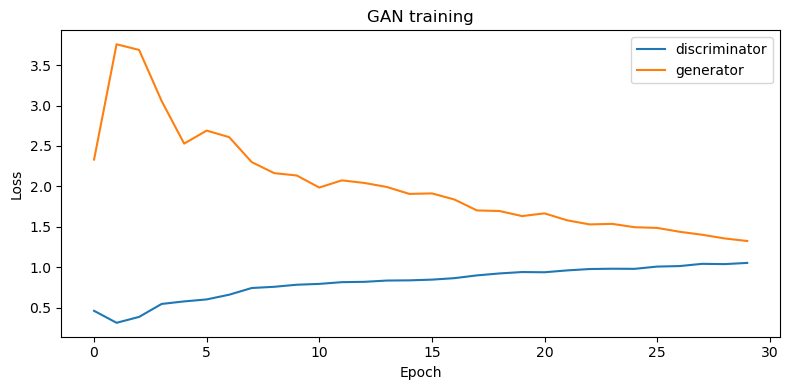

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(history_d, label='discriminator')
plt.plot(history_g, label='generator')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN training')
plt.legend()
plt.tight_layout()
plt.show()

## Generate Images

### Function

In [19]:
def show_samples(gen, n=8):
    """
    Plot a grid of generated images.

    Parameters:
        gen (nn.Module): Trained generator.
        n (int): Number of images to show.

    Returns:
        None
    """
    gen.eval()
    with torch.no_grad():
        noise = torch.randn(n, LATENT_DIM, device=DEVICE)
        images = gen(noise).cpu()
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
    for i in range(n):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].axis('off')
    fig.tight_layout()
    plt.show()

### Run

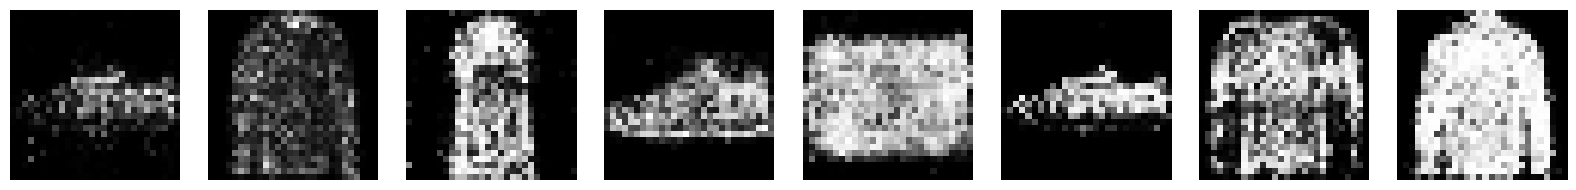

In [20]:
show_samples(generator, n=8)

## Save Models

In [21]:
torch.save(generator.state_dict(), 'gan_generator_fashion_mnist.pt')
torch.save(discriminator.state_dict(), 'gan_discriminator_fashion_mnist.pt')
print('saved gan models')

saved gan models


## Load Models

In [22]:
loaded_generator = Generator().to(DEVICE)
loaded_generator.load_state_dict(torch.load('gan_generator_fashion_mnist.pt', map_location=DEVICE))
loaded_generator.eval()
print('loaded gan_generator_fashion_mnist.pt')

loaded gan_generator_fashion_mnist.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_55391/1355962562.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_generator.load_state_dict(torch.load('

## Inference

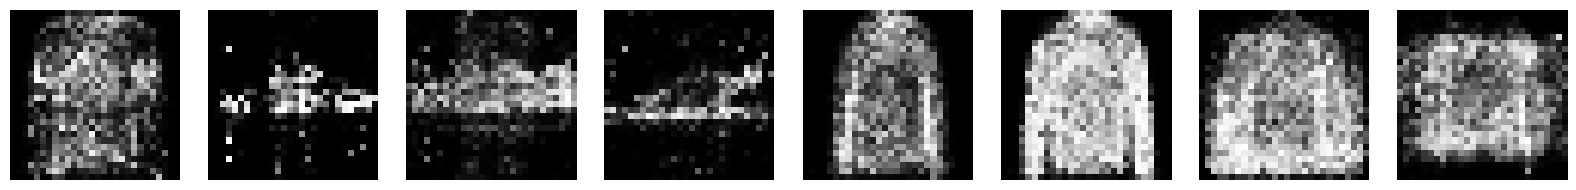

In [23]:
show_samples(loaded_generator, n=8)